# ActiTect API Example

## Loading a binary actigraphy file

Use `actitect.api.load(...)` to load any supported binary actigraphy file (Axivity: .cwa, GENEActiv: .bin, ActiGraph: .gt3x and .csv) into memory. This will return a time-indexed pandas.DataFrame object

In [1]:
from actitect.api import ensure_demo_asset
example_file_path = ensure_demo_asset()  # choose any filepath pointing to a supported file. Here, we download a provided example.

from actitect.api import load
raw_df, info = load(example_file_path, subject_id='ID-1')
print(raw_df.head(5))

/Users/david/anaconda3/envs/RBDisco/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 (18:00:30) - [actitect.actimeter.factory|INFO]: (io: ID-1) detected 'AxivityAx6' device.
 (18:00:30) - [actitect.actimeter.basedevice|INFO]: (io: ID-1) parsing data from 'example.cwa'.
 (18:00:40) - [actitect.utils.data_utils|INFO]: (io: ID-1) found 38 duplicate timestamps.removing ~0.38s of data
 (18:00:41) - [actitect.actimeter.basedevice|INFO]: (io: ID-1) successfully loaded raw data. (11.72s)
                                      x         y         z
time                                                       
2023-10-20 21:00:03.891418368 -0.684082 -0.160645  0.718506
2023-10-20 21:00:03.895416320 -0.689697 -0.163086  0.722900
2023-10-20 21:00:03.899414016 -0.694824 -0.160156  0.727051
2023-10-20 21:00:03.903411968 -0.692139 -0.158936  0.723145
2023-10-20 21:00:03.907409664 -0.685547 -0.161865  0.720947


## Visualizing actigraphy recordings
You can use ActiTect to visualize and inspect the recordings via `actitect.api.plot(...)`. It will draw the tri-axial sensor data, each row corresponding to one day of recording.

/var/folders/yw/nnsjt9xd2895vh6z2h298h100000gn/T/ipykernel_21586/740333084.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


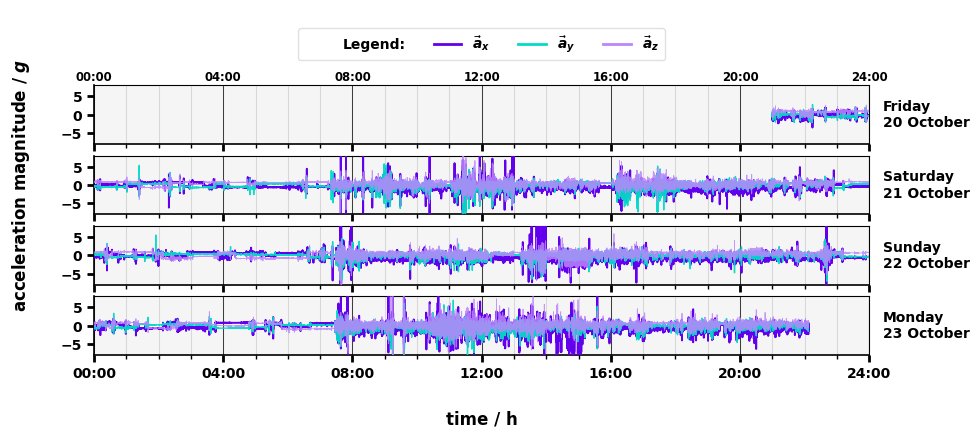

In [2]:
from actitect.api import plot

fig = plot(raw_df) # this will return a matplotlib.figure.Figure object
fig.show()

## Process actigraphy data
To process the actigraphy data use `actitect.api.process(...)`. This will by defualt apply
* **Uniform Resampling** to mitigate sample rate jitter (clock drifts etc)
* **Bandpass Filtering** to filter high and low frequency noise
* **Auto-Calibration** to ensure axes-alignment
* **Non-Wear Detection**
* **Sleep-Window Segmentation**

to the raw actigraphy data to mitigate artifacts and automatically segment non-wear and sleeping periods.

In [3]:
from actitect.api import process, plot

processed_df, info = process(raw_df, subject_id='ID-1') # you can also directly call process(file) one the filepath to load and process the data in one step
# 'info' is a dict that contains information about each processing step.

# plot the processed data
fig = plot(processed_df)
fig.show()

 (18:00:57) - [actitect.actimeter.factory|INFO]: (io: ID-1) detected 'Generic' device (preloaded DataFrame).
 (18:00:59) - [actitect.utils.data_utils|INFO]: (io: ID-1) no duplicate timestamps found.
 (18:01:00) - [actitect.actimeter.basedevice|INFO]: (resampling: ID-1) non-uniform sampling rate in raw data detected: fs = 100.05 ± 24.85 Hz
 (18:01:38) - [actitect.actimeter.basedevice|INFO]: (resampling: ID-1) successful. (37.74s)
 (18:01:41) - [actitect.actimeter.basedevice|INFO]: (filter: ID-1) successful. (3.22s)
 (18:01:46) - [actitect.actimeter.basedevice|INFO]: (calibration: ID-1) calibration error summary: before=18.35mg after=2.71mg.(62 iterations)
 (18:01:46) - [actitect.actimeter.basedevice|INFO]: (calibration: ID-1) successful. (5.10s)
 (18:01:49) - [actitect.actimeter.basedevice|INFO]: (non-wear: ID-1) wear-time-segmentation summary:wear=3.05d, non-wear=0.00d(0 episodes)
 (18:01:49) - [actitect.actimeter.basedevice|INFO]: (non-wear: ID-1) successful. (2.85s)


KeyboardInterrupt: 

the processed DataFrame will now store the processed data and have additional boolean columns 'wear', 'sptw' and 'sleep_bout' to indicate periods of non-wear (wear==False),  sleep period time windows (sptws==True). If you now call the plotting function, segements will me marked accordingly. If you do not want to use the default settings you can have full control over the processing steps:
```
processed_df = process(
    raw_df,
    resample_rate= 'infer',  # or int to set it directly to nominal sample rate in Hz, pass None to skip uniform resampling.
    highpass_hz= .8,  # or any other float to specify the lower cutoff of the bandpass filter in Hz, set None to skip it.
    lowpass_hz = 20.0, # or any other float to specify the upper cutoff of the bandpass filter in Hz, set None to skip it.
    calibrate=True,  # turn post-hoc auto-calibration on or off.
    detect_nonwear=True, # turn non-wear detection on or off.
    detect_sleep=True # turn sleep segmentation on or off.
)
```

## Feature extraction
Use `actitect.api.compute_sleep_motor_features()` to calculate numerical features from the sleep windows that characterize each nights motor patterns. For more details, refer to the main [README](../../README.md) and our paper.

In [ ]:
from actitect.api import compute_sleep_motor_features

features = compute_sleep_motor_features(processed_df)
print(features.head(3))
